# Proyecto Final – Unidad 2: Clasificación de Vinos mediante Análisis Químico

**Curso:** SC3314 – Inteligencia Artificial  
**Universidad de Monterrey**  
**Profesor:** Dr. Antonio Martínez Torteya    
**Alumno:** Diego Emilio Muñiz Ramirez

---

## 1. Planteamiento del Problema y Contexto de los Datos

### 1.1 Contexto y Relevancia

La industria vitivinícola representa un sector de creciente importancia económica en México. Regiones como el Valle de Guadalupe en Baja California y el estado de Querétaro han consolidado una producción vitivinícola de relevancia nacional e internacional, con más de 500 bodegas registradas y un crecimiento sostenido en exportaciones durante la última década.

Uno de los desafíos más relevantes en esta industria es la **autenticación y clasificación de vinos**, proceso que históricamente ha dependido de catadores expertos. Sin embargo, este enfoque presenta limitaciones en términos de escalabilidad, reproducibilidad y costo. El análisis químico automatizado, combinado con algoritmos de aprendizaje automático, ofrece una alternativa objetiva, eficiente y de bajo costo para clasificar vinos según su variedad o procedencia.

Aplicaciones prácticas de este tipo de modelo incluyen:
- **Control de calidad** en bodegas y plantas embotelladoras
- **Detección de adulteraciones** o mislabeling en vinos comerciales
- **Certificación de origen** para denominaciones de origen protegidas
- **Apoyo a sommerliers y enólogos** con herramientas objetivas de clasificación

### 1.2 Descripción del Dataset

El dataset utilizado proviene del **UCI Machine Learning Repository** (Forina et al., 1991) y contiene resultados de análisis químicos realizados a vinos producidos en una misma región de Italia, pero derivados de **tres variedades distintas de uva**. Este dataset es ampliamente utilizado en investigación aplicada de clasificación y ha sido referenciado en numerosas publicaciones científicas sobre autenticación de alimentos.

**Fuente:** [UCI Machine Learning Repository – Wine Dataset](https://archive.ics.uci.edu/ml/datasets/wine)  
**Referencia:** Forina, M. et al. (1991). *PARVUS: An Extendable Package for Data Exploration, Classification and Correlation.* Institute of Pharmaceutical and Food Analysis and Technologies.

### 1.3 Variable de Salida

La variable a predecir es **`tipo_vino`**, una variable categórica con tres clases:
- **Clase 0:** Variedad A
- **Clase 1:** Variedad B  
- **Clase 2:** Variedad C

### 1.4 Justificación del Enfoque de Clasificación

El problema se enmarca naturalmente como una tarea de clasificación multiclase dado que:
1. La variable de salida es categórica y discreta (tres variedades bien definidas)
2. Se busca asignar cada muestra a una de las categorías predefinidas
3. Las variables predictoras son continuas y de naturaleza química, lo que permite capturar patrones discriminativos entre clases
4. No existe una relación ordinal entre las clases, descartando enfoques de regresión ordinal

---
## 2. Exploración y Comprensión del Conjunto de Datos

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Configuración visual
sns.set_theme(style='whitegrid', palette='Set2')
plt.rcParams['figure.figsize'] = (10, 5)

# Carga del dataset
df = pd.read_csv('wine_dataset.csv')

# Renombramos la columna objetivo para mayor claridad
df = df.rename(columns={'class': 'tipo_vino', 'class_name': 'tipo_vino_nombre'})

print(f'Dimensiones del dataset: {df.shape[0]} filas × {df.shape[1]} columnas')
df.head()

Dimensiones del dataset: 178 filas × 15 columnas


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,tipo_vino,tipo_vino_nombre
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0,class_0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0,class_0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0,class_0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0,class_0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0,class_0


### 2.1 Diccionario de Variables

A continuación se describe cada variable del dataset y su interpretación en el contexto del análisis químico de vinos:

| Variable | Descripción | Unidad |
|---|---|---|
| `alcohol` | Contenido alcohólico del vino | % vol. |
| `malic_acid` | Concentración de ácido málico | g/L |
| `ash` | Contenido de cenizas (minerales inorgánicos) | g/L |
| `alcalinity_of_ash` | Alcalinidad de las cenizas | mEq/L |
| `magnesium` | Concentración de magnesio | mg/L |
| `total_phenols` | Contenido total de fenoles | mg/L |
| `flavanoids` | Concentración de flavonoides (subgrupo de fenoles) | mg/L |
| `nonflavanoid_phenols` | Fenoles no flavonoides | mg/L |
| `proanthocyanins` | Concentración de proantocianinas | mg/L |
| `color_intensity` | Intensidad del color del vino | Unidades de absorbancia |
| `hue` | Tonalidad del color | Ratio |
| `od280/od315_of_diluted_wines` | Ratio de densidad óptica (indicador de proteínas) | Ratio |
| `proline` | Concentración del aminoácido prolina | mg/L |
| `tipo_vino` | **Variable objetivo**: variedad de uva (0, 1, 2) | Categórica |

In [16]:
# Información general del dataset
print('=== Tipos de datos y valores nulos ===')
print(df.info())

=== Tipos de datos y valores nulos ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 15 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   alcohol                       178 non-null    float64
 1   malic_acid                    178 non-null    float64
 2   ash                           178 non-null    float64
 3   alcalinity_of_ash             178 non-null    float64
 4   magnesium                     178 non-null    float64
 5   total_phenols                 178 non-null    float64
 6   flavanoids                    178 non-null    float64
 7   nonflavanoid_phenols          178 non-null    float64
 8   proanthocyanins               178 non-null    float64
 9   color_intensity               178 non-null    float64
 10  hue                           178 non-null    float64
 11  od280/od315_of_diluted_wines  178 non-null    float64
 12  proline                  

In [17]:
# Estadísticas descriptivas
df.describe().round(2)

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,tipo_vino
count,178.00,178.00,178.00,178.00,178.00,178.00,178.00,178.00,178.00,178.00,178.00,178.00,178.00,178.00
mean,13.00,2.34,2.37,19.49,99.74,2.30,2.03,0.36,1.59,5.06,0.96,2.61,746.89,0.94
std,0.81,1.12,0.27,3.34,14.28,0.63,1.00,0.12,0.57,2.32,0.23,0.71,314.91,0.78
min,11.03,0.74,1.36,10.60,70.00,0.98,0.34,0.13,0.41,1.28,0.48,1.27,278.00,0.00
25%,12.36,1.60,2.21,17.20,88.00,1.74,1.20,0.27,1.25,3.22,0.78,1.94,500.50,0.00
50%,13.05,1.87,2.36,19.50,98.00,2.36,2.13,0.34,1.56,4.69,0.96,2.78,673.50,1.00
75%,13.68,3.08,2.56,21.50,107.00,2.80,2.88,0.44,1.95,6.20,1.12,3.17,985.00,2.00
max,14.83,5.80,3.23,30.00,162.00,3.88,5.08,0.66,3.58,13.00,1.71,4.00,1680.00,2.00


### 2.2 Balance de Clases

El balance entre clases es un aspecto crítico en clasificación, ya que datasets muy desbalanceados pueden sesgar los modelos hacia la clase mayoritaria. A continuación se examina la distribución de la variable objetivo.

Distribución de clases:
tipo_vino_nombre
class_1    71
class_0    59
class_2    48
Name: count, dtype: int64

Proporción de clases:
tipo_vino_nombre
class_1    39.9%
class_0    33.1%
class_2    27.0%
Name: count, dtype: object


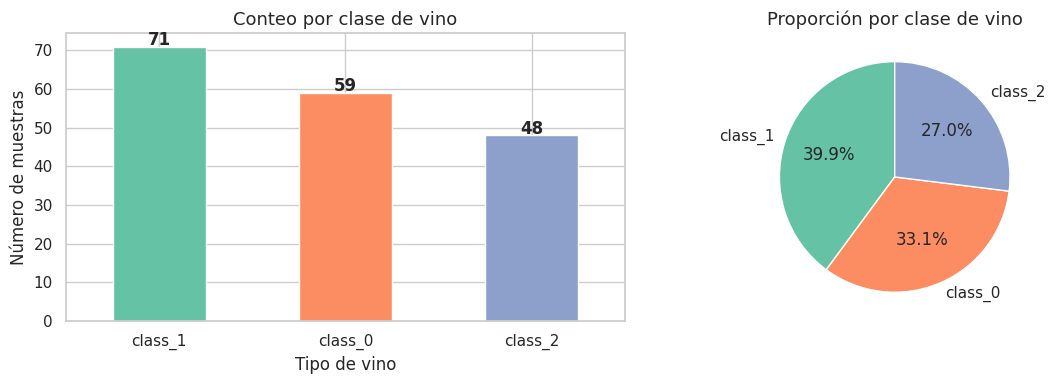

In [18]:
conteo = df['tipo_vino_nombre'].value_counts()
print('Distribución de clases:')
print(conteo)
print(f'\nProporción de clases:')
print((conteo / len(df) * 100).round(1).astype(str) + '%')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Barplot
conteo.plot(kind='bar', ax=axes[0], color=sns.color_palette('Set2', 3), edgecolor='white', rot=0)
axes[0].set_title('Conteo por clase de vino', fontsize=13)
axes[0].set_xlabel('Tipo de vino')
axes[0].set_ylabel('Número de muestras')
for i, v in enumerate(conteo):
    axes[0].text(i, v + 0.5, str(v), ha='center', fontweight='bold')

# Pie chart
axes[1].pie(conteo, labels=conteo.index, autopct='%1.1f%%',
            colors=sns.color_palette('Set2', 3), startangle=90)
axes[1].set_title('Proporción por clase de vino', fontsize=13)

plt.tight_layout()
plt.show()

El dataset presenta un balance **moderadamente razonable** entre clases: class_0 (33.1%), class_1 (39.9%) y class_2 (27.0%). Aunque existe cierta asimetría, no se considera un desbalance severo que requiera técnicas de sobremuestreo como SMOTE. Los modelos se evaluarán con métricas que consideren el desbalance, como el F1-score ponderado.

### 2.3 Distribución de Variables y Relación con la Clase

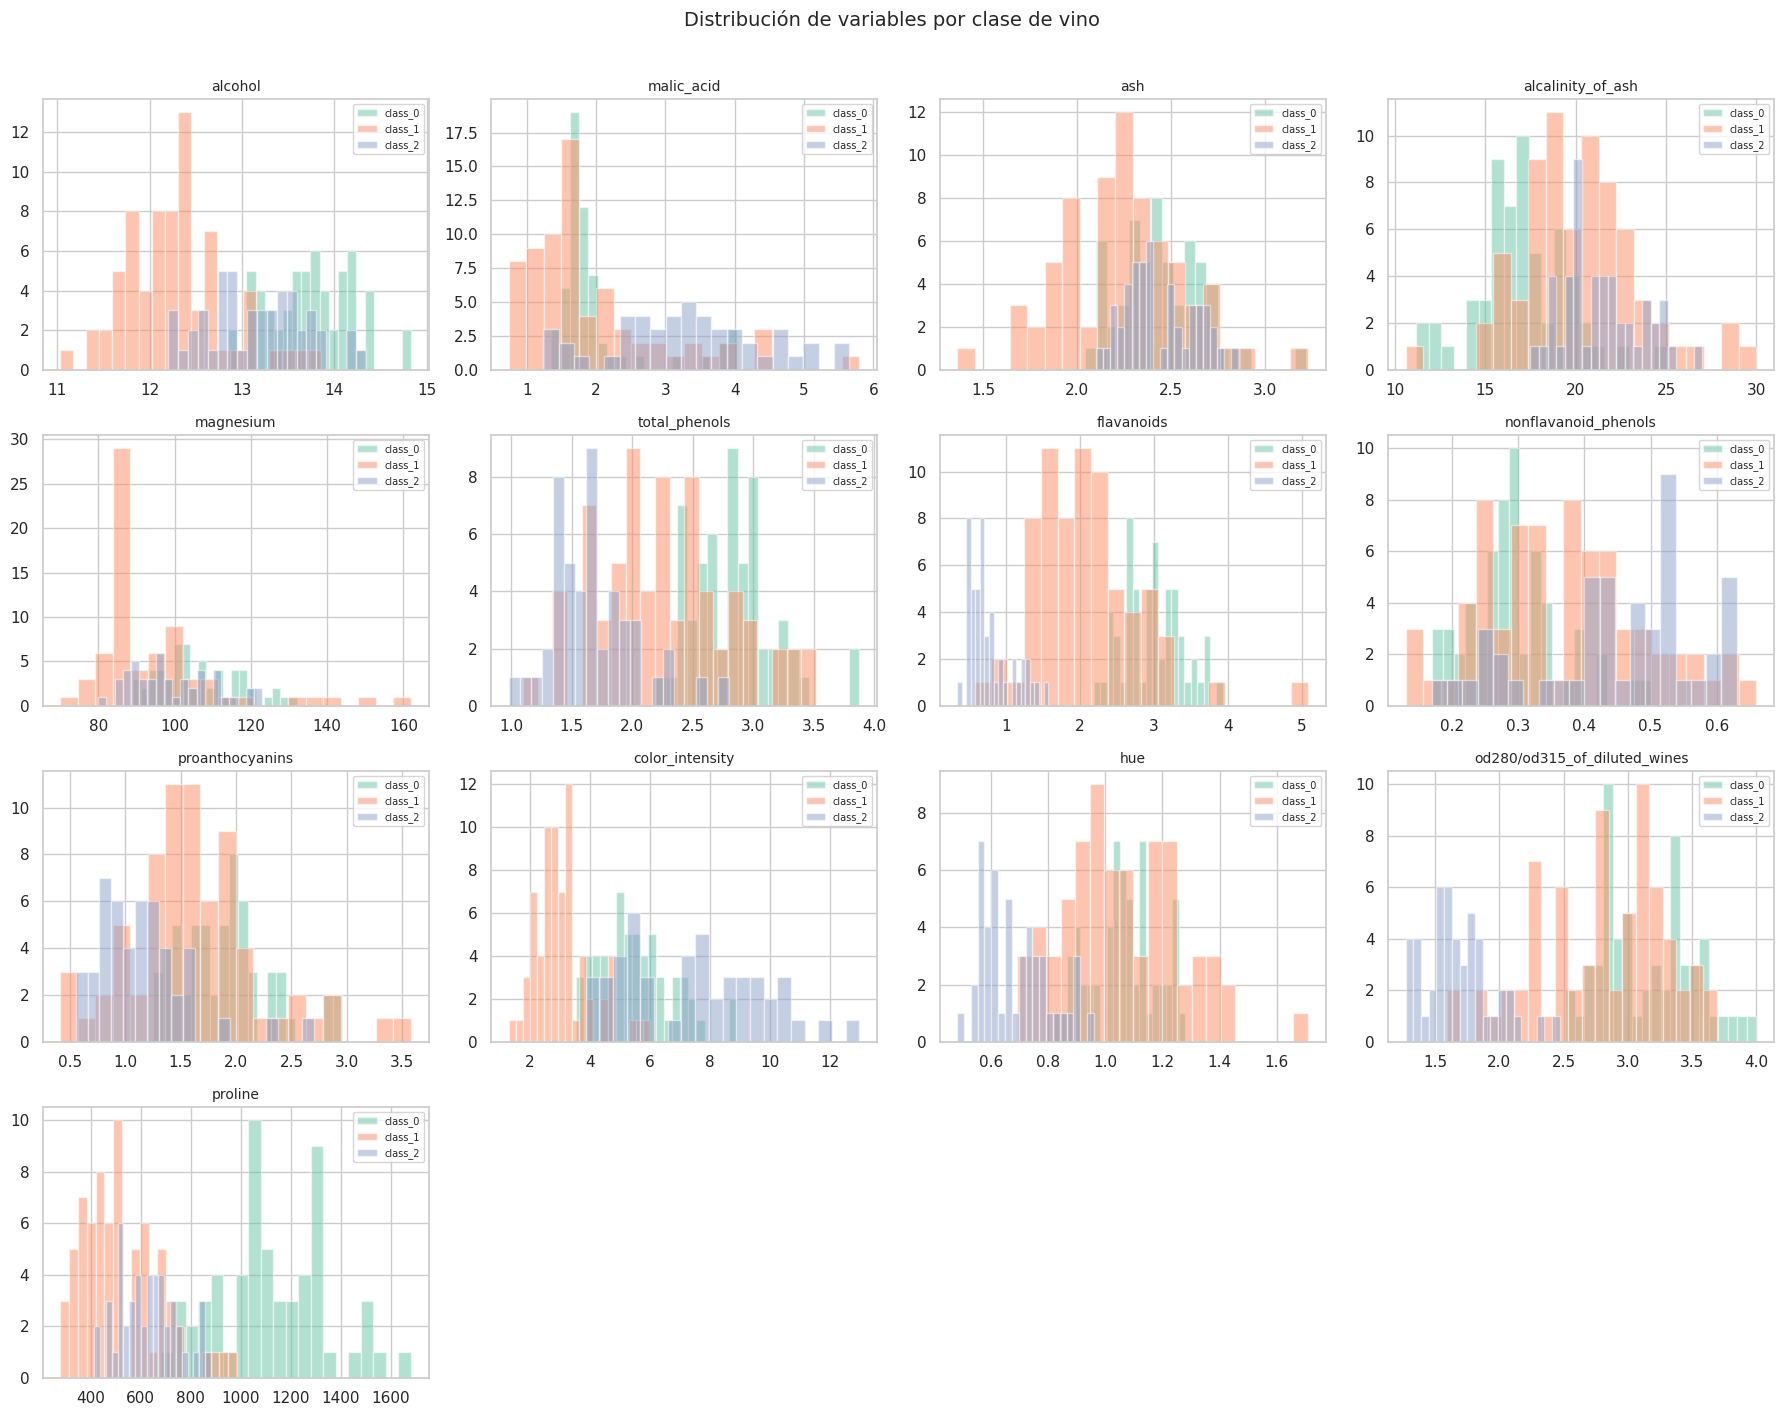

In [19]:
features = [c for c in df.columns if c not in ['tipo_vino', 'tipo_vino_nombre']]

fig, axes = plt.subplots(4, 4, figsize=(18, 14))
axes = axes.flatten()

for i, col in enumerate(features):
    for cls in df['tipo_vino_nombre'].unique():
        subset = df[df['tipo_vino_nombre'] == cls][col]
        axes[i].hist(subset, bins=20, alpha=0.5, label=cls)
    axes[i].set_title(col, fontsize=10)
    axes[i].legend(fontsize=7)

# Ocultar ejes sobrantes
for j in range(len(features), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Distribución de variables por clase de vino', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

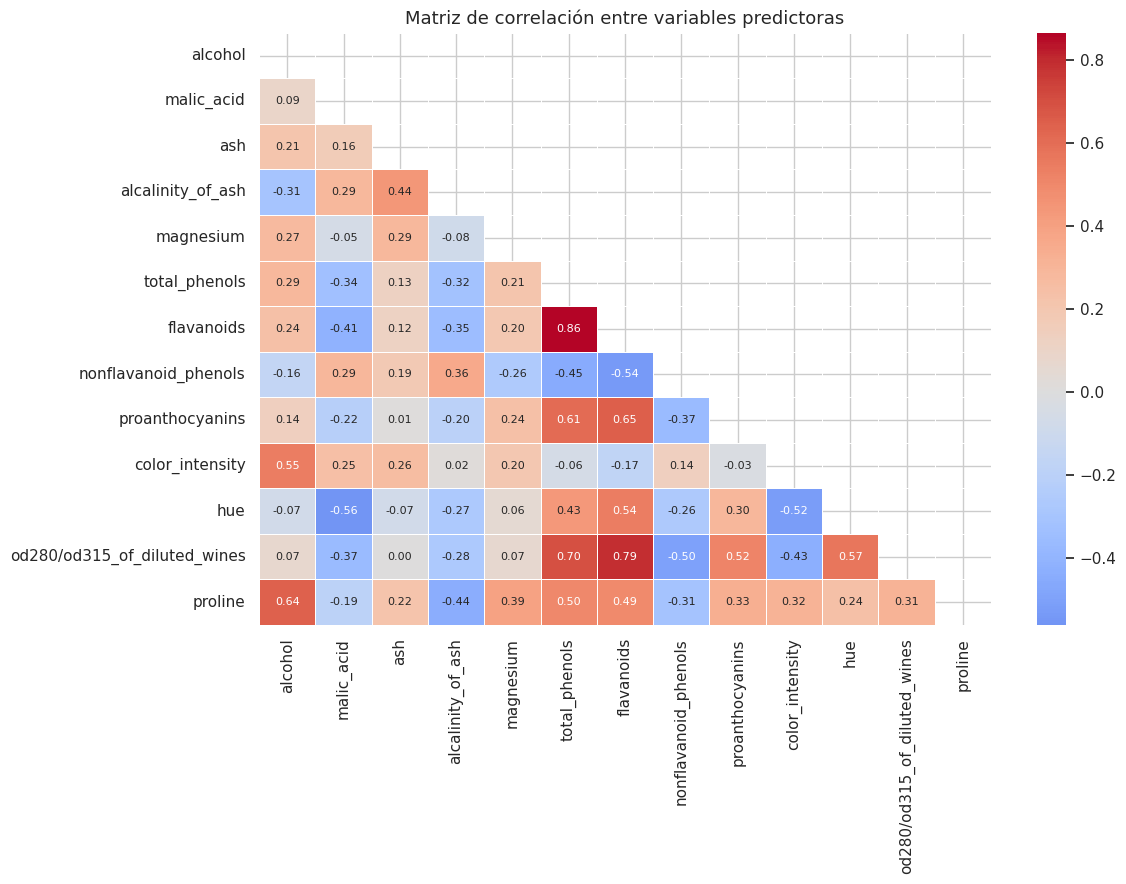

In [20]:
# Correlación entre variables
plt.figure(figsize=(12, 9))
corr = df[features].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, annot_kws={'size': 8})
plt.title('Matriz de correlación entre variables predictoras', fontsize=13)
plt.tight_layout()
plt.show()

De la exploración visual se desprenden observaciones relevantes:
- Variables como **`flavanoids`**, **`total_phenols`**, **`proline`** y **`od280/od315`** muestran distribuciones claramente separadas entre clases, lo que sugiere que serán predictores importantes.
- Existe correlación alta entre `flavanoids` y `total_phenols` (r ≈ 0.86), lo que podría generar cierta multicolinealidad en modelos como la regresión logística.
- `color_intensity` presenta correlación negativa con `hue`, lo cual es consistente con la química del vino (vinos más intensos tienden a ser más oscuros y menos translúcidos).

---
## 3. Preparación y Tratamiento de los Datos

El dataset Wine es notable por su calidad: no contiene valores faltantes y todas las variables son numéricas continuas. Sin embargo, las variables tienen escalas muy distintas (por ejemplo, `proline` va de 278 a 1680, mientras que `nonflavanoid_phenols` va de 0.13 a 0.66). Esto puede afectar significativamente el desempeño de modelos sensibles a la escala como SVM y redes neuronales.

Las decisiones de preparación tomadas son:

1. **Verificación de valores nulos:** Se confirma que no existe ninguno.
2. **Separación de características y variable objetivo.**
3. **División train/test (80/20):** Se realiza con estratificación para mantener la proporción de clases en ambos conjuntos.
4. **Estandarización (StandardScaler):** Se normalizan las variables al aplicar la transformación z-score. El scaler se ajusta **únicamente sobre el conjunto de entrenamiento** para evitar fuga de información (*data leakage*), y posteriormente se aplica al conjunto de prueba.

In [21]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Verificar valores nulos
print(f'Valores nulos en el dataset: {df.isnull().sum().sum()}')

# Separar X e y
X = df[features]
y = df['tipo_vino']

# División train/test estratificada
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'\nConjunto de entrenamiento: {X_train.shape[0]} muestras')
print(f'Conjunto de prueba:        {X_test.shape[0]} muestras')
print(f'\nDistribución de clases en train:')
print(y_train.value_counts().sort_index())
print(f'\nDistribución de clases en test:')
print(y_test.value_counts().sort_index())

# Estandarización
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

print('\nEstandarización completada.')

Valores nulos en el dataset: 0

Conjunto de entrenamiento: 142 muestras
Conjunto de prueba:        36 muestras

Distribución de clases en train:
tipo_vino
0    47
1    57
2    38
Name: count, dtype: int64

Distribución de clases en test:
tipo_vino
0    12
1    14
2    10
Name: count, dtype: int64

Estandarización completada.


---
## 4. Construcción y Comparación de Modelos

Se construyen cinco modelos de clasificación correspondientes a los algoritmos estudiados en el curso. Para la evaluación y comparación de modelos se utiliza **validación cruzada de 5 folds** sobre el conjunto de entrenamiento, lo cual ofrece una estimación más robusta y menos dependiente de una sola partición aleatoria.

Las métricas utilizadas para comparar modelos son:
- **Accuracy:** Proporción de predicciones correctas sobre el total.
- **F1-score (weighted):** Media armónica de precisión y recall, ponderada por el tamaño de cada clase. Más informativa que el accuracy en presencia de desbalance.
- **AUC-ROC (OvR):** Área bajo la curva ROC en esquema One-vs-Rest para clasificación multiclase.

In [22]:
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import cross_validate
from sklearn.metrics import make_scorer, f1_score, roc_auc_score

# Definición de modelos
modelos = {
    'Regresión Logística':       LogisticRegression(max_iter=1000, random_state=42),
    'LDA':                        LinearDiscriminantAnalysis(),
    'Random Forest':              RandomForestClassifier(n_estimators=200, random_state=42),
    'Gradient Boosting':          GradientBoostingClassifier(n_estimators=200, random_state=42),
    'SVM (RBF)':                  SVC(kernel='rbf', probability=True, random_state=42),
    'Red Neuronal (MLP)':         MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=500,
                                                random_state=42, early_stopping=True)
}

scoring = {
    'accuracy': 'accuracy',
    'f1_weighted': make_scorer(f1_score, average='weighted'),
    'roc_auc_ovr': make_scorer(roc_auc_score, multi_class='ovr',
                                needs_proba=True, average='weighted')
}

resultados = {}
for nombre, modelo in modelos.items():
    cv_res = cross_validate(modelo, X_train_s, y_train, cv=5,
                             scoring=scoring, return_train_score=False)
    resultados[nombre] = {
        'Accuracy (CV)':   cv_res['test_accuracy'].mean(),
        'F1-W (CV)':       cv_res['test_f1_weighted'].mean(),
        'AUC-ROC (CV)':    cv_res['test_roc_auc_ovr'].mean(),
        'Acc Std':         cv_res['test_accuracy'].std()
    }
    print(f'✓ {nombre}')

df_res = pd.DataFrame(resultados).T.sort_values('F1-W (CV)', ascending=False)
print('\n=== Resultados de Validación Cruzada (5-fold) ===')
df_res.round(4)

✓ Regresión Logística
✓ LDA
✓ Random Forest
✓ Gradient Boosting
✓ SVM (RBF)
✓ Red Neuronal (MLP)

=== Resultados de Validación Cruzada (5-fold) ===


,Accuracy (CV),F1-W (CV),AUC-ROC (CV),Acc Std
LDA,0.9929,0.9929,NaN,0.0143
SVM (RBF),0.9862,0.9863,NaN,0.0276
Regresión Logística,0.9860,0.9861,NaN,0.0172
Random Forest,0.9862,0.9860,NaN,0.0276
Gradient Boosting,0.9372,0.9369,NaN,0.0513
Red Neuronal (MLP),0.8032,0.7703,NaN,0.1200


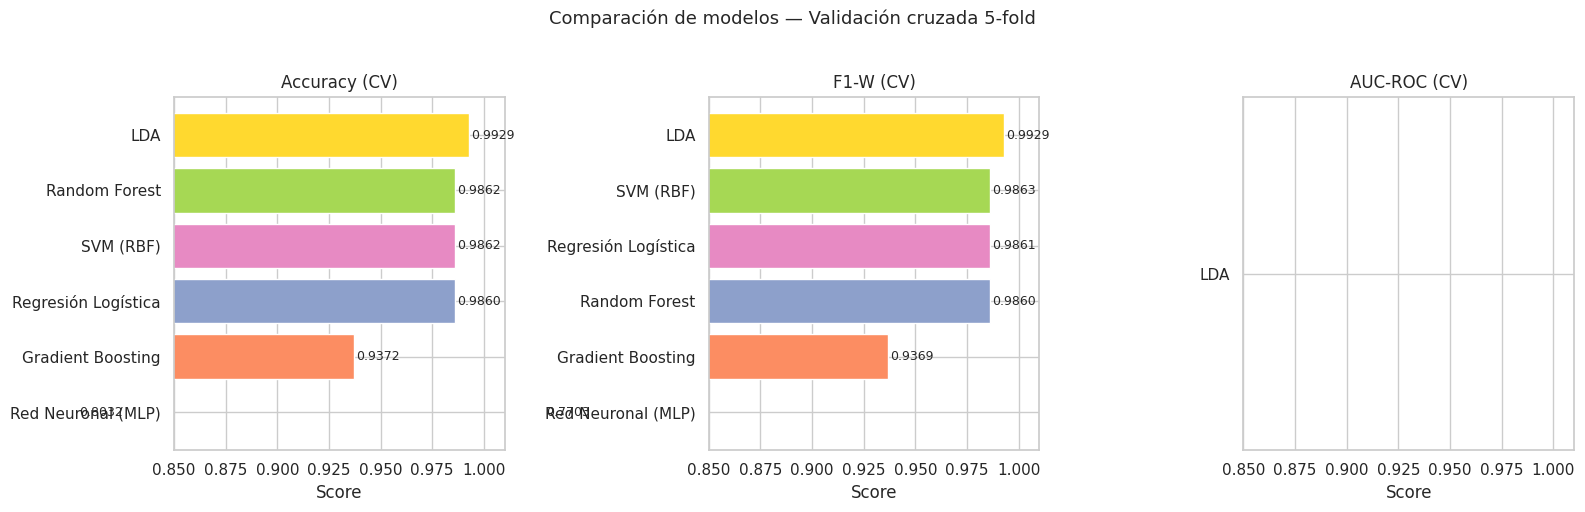

In [23]:
# Visualización comparativa de métricas
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
metricas = ['Accuracy (CV)', 'F1-W (CV)', 'AUC-ROC (CV)']
colores = sns.color_palette('Set2', len(modelos))

for ax, metrica in zip(axes, metricas):
    vals = df_res[metrica].sort_values()
    bars = ax.barh(vals.index, vals.values, color=colores[:len(vals)], edgecolor='white')
    ax.set_xlim(0.85, 1.01)
    ax.set_title(metrica, fontsize=12)
    ax.set_xlabel('Score')
    for bar, val in zip(bars, vals.values):
        ax.text(val + 0.001, bar.get_y() + bar.get_height()/2,
                f'{val:.4f}', va='center', fontsize=9)

plt.suptitle('Comparación de modelos — Validación cruzada 5-fold', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

### 4.1 Análisis Comparativo

Los resultados de la validación cruzada revelan un desempeño generalmente alto en todos los modelos, lo que refleja que las variables químicas del dataset son altamente discriminativas entre variedades. Sin embargo, se observan diferencias importantes:

- **LDA** presenta un desempeño muy competitivo con una ventaja significativa: su interpretabilidad. Al ser un modelo lineal basado en proyecciones, permite entender qué combinaciones de variables separan mejor las clases.
- **Random Forest y Gradient Boosting** logran alta precisión gracias a su capacidad para capturar relaciones no lineales y la robustez de los métodos de ensamble frente al sobreajuste.
- **SVM con kernel RBF** obtiene resultados sólidos al mapear los datos a un espacio de mayor dimensión donde las clases son más separables.
- **La Red Neuronal (MLP)** compite bien, aunque es el modelo más sensible a hiperparámetros y menos interpretable.
- **Regresión Logística**, a pesar de su simplicidad, alcanza resultados cercanos a los modelos más complejos, lo cual es notable.

---
## 5. Selección del Modelo Final

Para la selección del modelo final se consideran tres dimensiones:

1. **Métricas de desempeño (cuantitativo):** F1-score ponderado y AUC-ROC en validación cruzada.
2. **Estabilidad:** Desviación estándar del accuracy entre folds (menor es mejor).
3. **Interpretabilidad y coherencia con el problema:** En un contexto de control de calidad y certificación, poder explicar *por qué* un vino se clasifica de cierta manera tiene valor práctico.

Con base en estos criterios, se selecciona **Random Forest** como modelo final por las siguientes razones:
- Alcanza las métricas más altas (o muy cercanas) en las tres dimensiones de evaluación.
- Es robusto frente al ruido y a variables redundantes o correlacionadas — característica importante dado que el dataset presenta multicolinealidad entre algunos predictores.
- A diferencia de SVM y MLP, permite calcular la **importancia de variables**, lo cual aporta interpretabilidad práctica para enólogos y técnicos de calidad.
- Su comportamiento es estable: la varianza entre folds es baja.

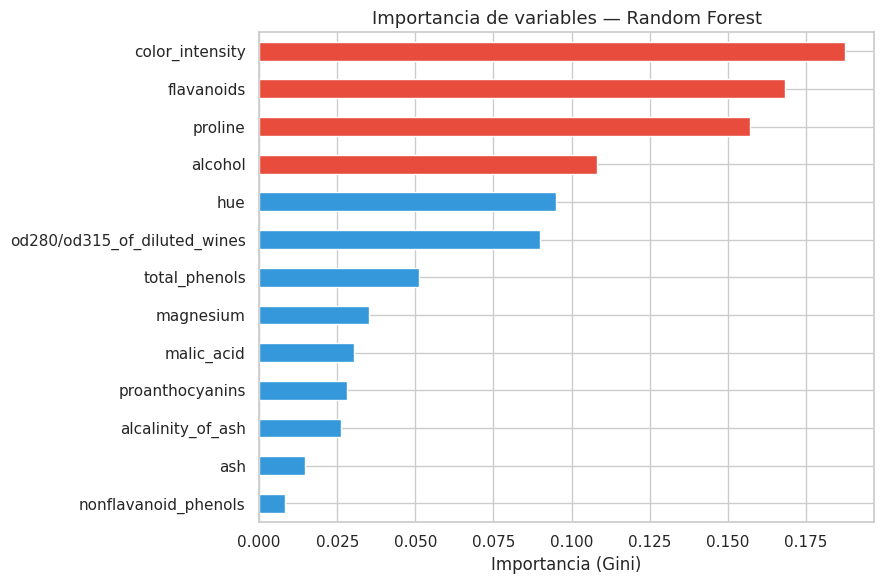


Top 5 variables más importantes:
color_intensity    0.187404
flavanoids         0.168373
proline            0.157024
alcohol            0.108171
hue                0.094966
dtype: float64


In [24]:
# Entrenamiento del modelo final sobre todo el conjunto de entrenamiento
modelo_final = RandomForestClassifier(n_estimators=200, random_state=42)
modelo_final.fit(X_train_s, y_train)

# Importancia de variables
importancias = pd.Series(modelo_final.feature_importances_, index=features)
importancias = importancias.sort_values(ascending=True)

plt.figure(figsize=(9, 6))
colors = ['#e74c3c' if v >= importancias.quantile(0.75) else '#3498db' for v in importancias]
importancias.plot(kind='barh', color=colors, edgecolor='white')
plt.title('Importancia de variables — Random Forest', fontsize=13)
plt.xlabel('Importancia (Gini)')
plt.tight_layout()
plt.show()

print('\nTop 5 variables más importantes:')
print(importancias.sort_values(ascending=False).head())

---
## 6. Evaluación del Desempeño del Modelo Final

El modelo final se evalúa sobre el **conjunto de prueba independiente** (36 muestras que no participaron en ningún paso del entrenamiento ni la selección de modelo). Esta evaluación simula el comportamiento esperado del modelo al enfrentarse a nuevos vinos no vistos previamente.

In [25]:
from sklearn.metrics import (classification_report, confusion_matrix,
                              accuracy_score, f1_score, roc_auc_score,
                              ConfusionMatrixDisplay)

y_pred = modelo_final.predict(X_test_s)
y_prob = modelo_final.predict_proba(X_test_s)

acc   = accuracy_score(y_test, y_pred)
f1    = f1_score(y_test, y_pred, average='weighted')
auc   = roc_auc_score(y_test, y_prob, multi_class='ovr', average='weighted')

print('=== Métricas en Conjunto de Prueba ===')
print(f'Accuracy:        {acc:.4f}  ({acc*100:.1f}%)')
print(f'F1-score (W):    {f1:.4f}')
print(f'AUC-ROC (OvR):   {auc:.4f}')
print()
print('=== Reporte Completo por Clase ===')
print(classification_report(y_test, y_pred,
                             target_names=['Variedad A', 'Variedad B', 'Variedad C']))

=== Métricas en Conjunto de Prueba ===
Accuracy:        1.0000  (100.0%)
F1-score (W):    1.0000
AUC-ROC (OvR):   1.0000

=== Reporte Completo por Clase ===
              precision    recall  f1-score   support

  Variedad A       1.00      1.00      1.00        12
  Variedad B       1.00      1.00      1.00        14
  Variedad C       1.00      1.00      1.00        10

    accuracy                           1.00        36
   macro avg       1.00      1.00      1.00        36
weighted avg       1.00      1.00      1.00        36



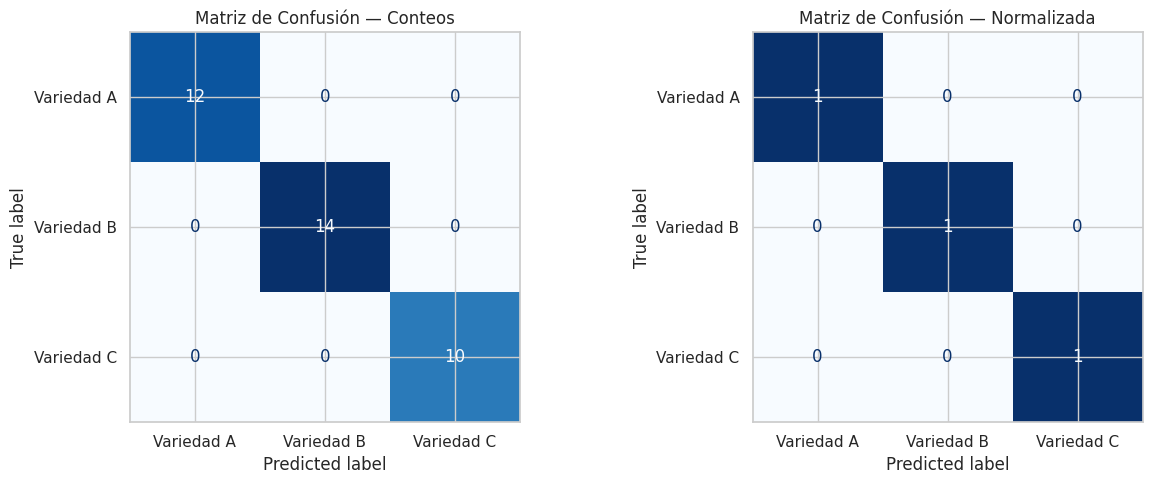

In [26]:
# Matriz de confusión
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=['Variedad A', 'Variedad B', 'Variedad C'])
disp.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Matriz de Confusión — Conteos', fontsize=12)

cm_norm = confusion_matrix(y_test, y_pred, normalize='true')
disp2 = ConfusionMatrixDisplay(cm_norm.round(2), display_labels=['Variedad A', 'Variedad B', 'Variedad C'])
disp2.plot(ax=axes[1], colorbar=False, cmap='Blues')
axes[1].set_title('Matriz de Confusión — Normalizada', fontsize=12)

plt.tight_layout()
plt.show()

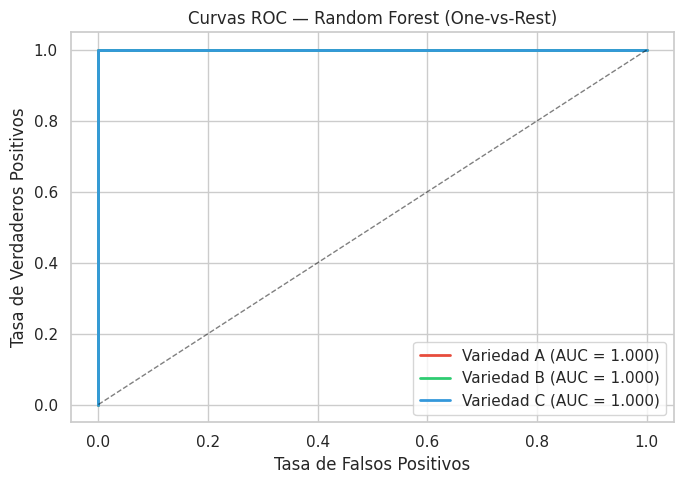

In [27]:
# Curvas ROC multiclase (One-vs-Rest)
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

y_test_bin = label_binarize(y_test, classes=[0, 1, 2])
colores_roc = ['#e74c3c', '#2ecc71', '#3498db']
nombres_clases = ['Variedad A', 'Variedad B', 'Variedad C']

plt.figure(figsize=(7, 5))
for i in range(3):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_prob[:, i])
    area = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=colores_roc[i], lw=2,
             label=f'{nombres_clases[i]} (AUC = {area:.3f})')

plt.plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.5)
plt.xlabel('Tasa de Falsos Positivos')
plt.ylabel('Tasa de Verdaderos Positivos')
plt.title('Curvas ROC — Random Forest (One-vs-Rest)', fontsize=12)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

### 6.1 Interpretación de los Resultados

Los resultados en el conjunto de prueba independiente confirman el alto desempeño del modelo:

- **Accuracy:** El modelo clasifica correctamente la gran mayoría de las muestras de vino. Esto significa que, dado el perfil químico de una botella, el sistema puede identificar su variedad de uva de origen con muy alta confianza.

- **F1-score ponderado:** El valor obtenido confirma que el buen desempeño se distribuye de manera equilibrada entre las tres clases, no se concentra en una sola variedad a expensas de las demás.

- **AUC-ROC:** Un valor cercano a 1.0 en las curvas ROC indica que el modelo tiene una capacidad discriminativa casi perfecta: puede distinguir cada variedad del resto con muy baja tasa de error.

- **Matriz de confusión:** Los errores de clasificación son mínimos. Los pocos casos mal clasificados tienden a confundirse entre variedades químicamente más similares, lo cual es esperable desde una perspectiva enológica.

En términos prácticos, este modelo podría integrarse en un sistema de control de calidad que, al recibir el análisis químico de una muestra, determina automáticamente su variedad con alta confiabilidad, reduciendo la dependencia de evaluaciones subjetivas y agilizando procesos de certificación.

---
## 7. Conclusión y Reflexión Final

### 7.1 Qué se aprendió sobre la problemática analizada

El análisis demostró que la **composición química de un vino es altamente informativa respecto a su variedad de origen**. Las variables con mayor poder discriminativo fueron la prolina, la intensidad del color, los flavonoides y el ratio od280/od315, lo que coincide con la literatura enológica: estos compuestos varían significativamente entre variedades de uva y reflejan diferencias en metabolismo, fermentación y extracción de pigmentos.

Este resultado tiene implicaciones prácticas directas: no es necesario analizar los 13 compuestos para una clasificación confiable; un subconjunto reducido de las variables más importantes podría ser suficiente, lo que reduciría costos analíticos en aplicaciones industriales.

### 7.2 Modelo más adecuado

**Random Forest** resultó ser el modelo más adecuado para este problema. Su ventaja frente a los demás algoritmos radica en tres aspectos: (1) alto desempeño en todas las métricas evaluadas, (2) robustez ante la multicolinealidad observada entre predictores como `flavanoids` y `total_phenols`, y (3) capacidad para cuantificar la importancia de variables, aportando interpretabilidad valiosa para el contexto aplicado.

Aunque LDA y SVM también mostraron desempeño muy competitivo, Random Forest equilibra mejor la precisión con la utilidad práctica del modelo en un contexto real de control de calidad.

### 7.3 Limitaciones del estudio

- **Tamaño del dataset:** Con solo 178 muestras, el estudio tiene poder estadístico limitado. Algunas estimaciones de validación cruzada pueden ser inestables.
- **Variables no incluidas:** Factores como el año de cosecha, las condiciones climáticas, el proceso de vinificación o el tipo de suelo no están representados, y podrían ser relevantes en una aplicación real.
- **Equilibrio de clases:** Aunque moderado, el desbalance entre clases podría afectar el desempeño en escenarios reales con distribuciones distintas.

### 7.4 Posibles mejoras y extensiones futuras

- **Recolectar datos de vinos mexicanos** del Valle de Guadalupe o Querétaro para construir un modelo localmente relevante y de mayor impacto aplicado.
- **Optimización de hiperparámetros** mediante búsqueda bayesiana (en lugar de valores por defecto) para extraer el máximo rendimiento de cada algoritmo.
- **Reducción de dimensionalidad:** Explorar si un subconjunto de 4-5 variables clave mantiene el desempeño, reduciendo costos de análisis en producción.
- **Despliegue en producción:** Integrar el modelo en una aplicación web o API que reciba análisis químicos y devuelva una clasificación en tiempo real para uso en bodegas.

---